# <u>Submission instructions</u>
### Submission in pairs unless otherwise authorized
<ul style="font-size: 17px">
<li> This notebook contains all the questions. You should follow the instructions below.</li>
<li> Solutions for both theoretical and practical parts should be provided in this notebook</li>
</ul>

<h3> Moodle submission</h3>


<p style="font-size: 17px">
You should submit three files:
</p>
<ul style="font-size: 17px">
<li>IPYNB notebook:
  <ul>
  <li>All the wet and dry parts, including code, graphs, discussion, etc.</li>
  </ul>
</li>
<li>PDF file:
  <ul>
  <li>Export the notebook to PDF. Make sure that all the cells are visible.</li>
  </ul>
</li>
<li>Pickle files:
  <ul>
    <li>As requested in Q3.2.a and Q4.a</li>
  </ul>
</li>
</ul>
<p style="font-size: 17px">
All files should be in the following format: "HW1_ID1_ID2.file"
<br>
Good Luck!
</p>

# Question 1 (15pt)

We mentioned in the lecture and tutorial that neural networks, thanks to their non-linear activation functions, can express a much wider range of functions than just linear ones.

In each of the following exercises, you are given the weight matrices, biases and activations of a small neural network. Express the network's output as a simplified, well-known mathematical function and provide a short explanation. There is no need to prove correctness, an intuitive explanation is enough.

The activation function (non-linearity) is denoted as $g$. The output is given by:

$$s = W_2 g(W_1 x + b_1) + b_2.$$

In network 4, we also apply the activation to the final output, meaning the network's output is $g(s)$. When not stated otherwise, the bias vector is 0.

### Network 1

$$x \in \mathbb{R}. \quad W_1=\begin{pmatrix} 1 \\ -1\end{pmatrix}, W_2 = \begin{pmatrix} 1 & 1\end{pmatrix}. \quad g=\text{ReLU}.$$

**Final function:**  
The network computes the absolute value function: $$s = |x|$$


**Explanation:**  
The first layer maps the input \(x\) to two values: \(x\) and \(-x\).  
After applying the ReLU activation, only the positive part of each remains.  
The second layer then sums these two activated values.  

If \(x > 0\), the output is \(x\).  
If \(x < 0\), the output is \(-x\).  

Thus, regardless of the sign of \(x\), the network outputs \(|x|\).

### Network 2

$$x \in \mathbb{R}^2. \quad W_1 = \begin{pmatrix}-1 & 1 \\ 1 & 0 \\ -1 & 0\end{pmatrix}, W_2 = \begin{pmatrix}1 & 1 & -1\end{pmatrix}. \quad g=\text{ReLU}.$$

**Final function:**
$$
s = \max(x_1, x_2)
$$

**Explanation:**

The first layer produces:
$$
h_1 = \max(0, x_2 - x_1), \quad
h_2 = \max(0, x_1), \quad
h_3 = \max(0, -x_1)
$$

The second layer computes:
$$
s = h_1 + h_2 - h_3
$$

Since:
$$
\max(0, x_1) - \max(0, -x_1) = x_1
$$

we get:
$$
s = x_1 + \max(0, x_2 - x_1)
$$

If $x_2 \le x_1$, the ReLU term is zero and $s = x_1$.  
If $x_2 > x_1$, the ReLU term becomes $x_2 - x_1$ and $s = x_2$.

Thus:
$
s = \max(x_1, x_2)
$

### Network 3

$$x=\begin{pmatrix}x_1 \\ x_2 \\ y_1 \\ y_2\end{pmatrix} \in \mathbb{R}^4. \quad W_1 = \begin{pmatrix} 1 & 0 & -1 & 0 \\ -1 & 0 & 1 & 0 \\ 0 & 1 & 0 & -1 \\ 0 & -1 & 0 & 1\end{pmatrix}, W_2 = \begin{pmatrix} 1 & 1 & 1 & 1 \end{pmatrix}. \quad g = \text{ReLU}.$$

**Final function:** $$s = |x_1 - y_1| + |x_2 - y_2|$$


**Explanation:**
The first layer computes four signed differences:
$$(x_1 - y_1),\; (y_1 - x_1),\; (x_2 - y_2),\; (y_2 - x_2)$$


After applying ReLU, only positive parts remain.  
Summing all four terms gives:

first pair
$$
\max(0, x_1 - y_1) + \max(0, y_1 - x_1)
= |x_1 - y_1|
$$

And likewise for the second pair:
$$
\max(0, x_2 - y_2) + \max(0, y_2 - x_2)
= |x_2 - y_2|
$$

Thus the network outputs the L1 (Manhattan) distance between the points \$$(x_1, x_2) and (y_1, y_2)$$

### Network 4

Here, the non-linearity is applied also to the output of the second layer. For simplicity, assume $ \forall x \ge 10, \text{sigmoid}(x) = 1, \text{sigmoid}(-x) = 0$.

$$x \in \{0, 1\}^2 \quad \text{(binary vector)}.$$

$$W_1 = \begin{pmatrix} 20 & 20 \\ -20 & -20 \end{pmatrix}, b_1 = \begin{pmatrix} -10 \\ 30 \end{pmatrix}, W_2 = \begin{pmatrix} 20 & 20 \end{pmatrix}, b_2 = -30. \quad g=\text{sigmoid}.$$

**Final function:**
$$
s = x_1 \oplus x_2
$$

**Explanation:**

Since the inputs are binary and the sigmoid is approximated as a hard threshold  
$≥ 10 → 1, ≤ −10 → 0$, the network behaves like a logical circuit.

The first layer outputs:
- (0, 1) when both inputs are 0  
- (1, 1) when exactly one input is 1  
- (1, 0) when both inputs are 1  

The second layer then computes:
$
s = 20h_1 + 20h_2 - 30
$
and applies the same thresholded sigmoid to produce the final output.

This yields the truth table:

| x₁ | x₂ | output |
|----|----|---------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Thus, the network outputs 1 only when exactly one input is 1,  
which corresponds to the XOR function.

# Question 2

We recommend checking the hidden slides in tutorial 1 before approaching these exercises.

## I. Softmax Derivative (5pt)

Derive the gradients of the softmax function and demonstrate how the expression can be reformulated solely by using the softmax function, i.e., in some expression where only $\text{softmax}(x)$, but not $x$, is present. Recall that the softmax function is defined as follows:

$$\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_{j=1}^{N} e^{x_j}}$$

### I. Softmax Derivative - Answer:
$$\frac{\partial softmax(x)_i}{\partial x_k} = $$

We start from:

$$
s_i = \text{softmax}(x)_i = \frac{e^{x_i}}{Z}
\qquad\text{with}\qquad
Z = \sum_{j=1}^N e^{x_j}
$$

We apply the quotient rule:

$$
\frac{\partial s_i}{\partial x_k}
=
\frac{
\delta_{ik} e^{x_i} \cdot Z
-
e^{x_i} \cdot e^{x_k}
}{Z^2}
$$

Here, $\delta_{ik}$ is equals 1 when $i = k$ and 0 otherwise.

Factor out $e^{x_i}$:

$$
\frac{\partial s_i}{\partial x_k}
= \frac{e^{x_i}}{Z^2} \left( \delta_{ik} Z - e^{x_k} \right)
$$

Since:

$$
s_i = \frac{e^{x_i}}{Z}
\qquad\text{and}\qquad
s_k = \frac{e^{x_k}}{Z}
$$

we get:

$$
\frac{\partial s_i}{\partial x_k}
= s_i (\delta_{ik} - s_k)
$$

Thus:

$$
\boxed{
\frac{\partial \, \text{softmax}(x)_i}{\partial x_k}
=
\text{softmax}(x)_i (\delta_{ik} - \text{softmax}(x)_k)
}
$$

which depends only on **softmax(x)**, and not on x.

## II. Cross-Entropy Gradient (5pt)

Derive the gradient of cross-entropy loss with regard to the inputs of a softmax function. i.e., find the gradients with respect to the softmax input vector $\theta$, when the prediction is denoted by $\hat{y} = \text{softmax}(\theta)$. Remember the cross entropy function is:
$$CE(y, \hat{y}) = -\sum_i y_i log(\hat{y_i})$$


where $y$ is the one-hot label vector, and $\hat{y}$ is the predicted probability vector for all classes.

### II. Cross-Entropy Gradient - Answer

<!--- write your answer -->
$$\frac{\partial CE(y, \hat{y})}{\partial\theta} = \frac{\partial}{\partial\theta} \Big( - \sum_{i=1}^N y_i \log(\hat{y}_i) \Big)$$

We know that:
$$\hat{y}_i = \text{softmax}(\theta)_i = \frac{e^{\theta_i}}{\sum_{j=1}^N e^{\theta_j}}$$

We apply the chain rule:
$$\frac{\partial CE}{\partial \theta_k}
= \sum_{i=1}^N \frac{\partial CE}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial \theta_k}$$

First term:
$$\frac{\partial CE}{\partial \hat{y}_i} = -\frac{y_i}{\hat{y}_i}$$

Second term :
$$
\frac{\partial \hat{y}_i}{\partial \theta_k}
= \frac{\partial}{\partial \theta_k} \left( \frac{e^{\theta_i}}{\sum_j e^{\theta_j}} \right)
= \frac{\delta_{ik} e^{\theta_i} \cdot \sum_j e^{\theta_j} - e^{\theta_i} \cdot e^{\theta_k}}{\left( \sum_j e^{\theta_j} \right)^2}
= \frac{e^{\theta_i}}{\sum_j e^{\theta_j}} \left( \delta_{ik} - \frac{e^{\theta_k}}{\sum_j e^{\theta_j}} \right)
= \hat{y}_i (\delta_{ik} - \hat{y}_k)
$$

We multiply them:
$$\frac{\partial CE}{\partial \theta_k}
= \sum_{i=1}^N \left( -\frac{y_i}{\hat{y}_i} \right) \cdot \hat{y}_i (\delta_{ik} - \hat{y}_k)$$

The $\hat{y}_i$ cancels:
$$\frac{\partial CE}{\partial \theta_k}
= - \sum_{i=1}^N y_i (\delta_{ik} - \hat{y}_k)$$

Because $y$ is one-hot, only one $y_i$ is nonzero (the true class), and $\sum_i y_i = 1$:

Thus the expression simplifies to:
$$\frac{\partial CE}{\partial \theta_k} = \hat{y}_k - y_k$$

**Final Result:**
$$\boxed{\frac{\partial CE(y, \hat{y})}{\partial\theta} = \hat{y} - y}$$

# Question 3

## I. Derivative Of Activation Functions (5pt)

The following cell contains an implementation of some activation functions. Implement the corresponding derivatives.

In [1]:
import torch

def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def tanh(x):
    return torch.div(torch.exp(x) - torch.exp(-x), torch.exp(x) + torch.exp(-x))


def softmax(x):
    exp_x = torch.exp(x.T - torch.max(x, dim=-1).values).T  # Subtracting max(x) for numerical stability
    return exp_x / exp_x.sum(dim=-1, keepdim=True)

In [2]:
def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)


def d_tanh(x):
    t = tanh(x)
    return 1 - t**2


def d_softmax(x):
    # softmax(x) shape: (batch, classes)
    y = torch.exp(x - x.max(dim=-1, keepdim=True).values)
    y = y / y.sum(dim=-1, keepdim=True)

    # y shape: (batch, C)
    batch, C = y.shape

    # Expand to build Jacobian: (batch, C, C)
    y_i = y.unsqueeze(2)          # (batch, C, 1)
    y_j = y.unsqueeze(1)          # (batch, 1, C)

    # Jacobian: diag(y) - y_i * y_j
    J = torch.eye(C).to(x) * y.unsqueeze(2) - y_i * y_j
    return J


## II. Train a Fully Connected network on MNIST (30pt)

In the following exercise, you will create a classifier for the MNIST dataset.
You should write your own training and evaluation code and meet the following
constraints:
<ul>
<li> You are only allowed to use torch tensor manipulations.</li>
<li> You are NOT allowed to use:
  <ul>
  <li> Auto-differentiation - backward()</li>
  <li> Built-in loss functions</li>
  <li> Built-in activations</li>
  <li> Built-in optimization</li>
  <li> Built-in layers (torch.nn)</li>
  </ul>
  </li>
</ul>
</h4>

a. The required classifier class is defined.

You should implement the forward and backward passes of the model.
Train the model and plot the model's accuracy and loss (both on train and test sets) as a function of the epochs.
You should save the model's weights and biases. Change the student_ids to yours.

In this section, you <b>must</b> use the "set_seed" function with the given seed and <b>sigmoid</b> as an activation function.

In [3]:
import torch
import torchvision
from torch.utils.data import DataLoader

import os
import matplotlib.pyplot as plt

# Constants
SEED = 42
EPOCHS = 16
BATCH_SIZE = 32
NUM_OF_CLASSES = 10

# Setting seed
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


# Transformation for the data
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torch.flatten])


# Cross-Entropy loss implementation
def one_hot(y, num_of_classes=10):
    hot = torch.zeros((y.size()[0], num_of_classes))
    hot[torch.arange(y.size()[0]), y] = 1
    return hot

def cross_entropy(y, y_hat):
    return -torch.sum(one_hot(y) * torch.log(y_hat)) / y.size()[0]



In [4]:
# Create dataloaders
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE)


test_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                           download=True, transform=transform)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE,)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 349kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]


In [5]:
class FullyConnectedNetwork:
    def __init__(self, input_size, output_size, hidden_size1, activiation_func, lr=0.01):
        # parameters
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size1 = hidden_size1

        # activation function
        self.activation_func = activiation_func

        # weights
        self.W1 = torch.randn(self.input_size, self.hidden_size1)
        self.b1 = torch.zeros(self.hidden_size1)

        self.W2 = torch.randn(self.hidden_size1, self.output_size)
        self.b2 = torch.zeros(self.output_size)

        self.lr = lr

    def forward(self, x):

        # First layer
        self.z1 = torch.matmul(x, self.W1) + self.b1
        self.h = self.activation_func(self.z1)

        # Second layer
        self.z2 = torch.matmul(self.h, self.W2) + self.b2
        return softmax(self.z2)


    def backward(self, x, y, y_hat):

        batch_size = y.size(0)

        Y = one_hot(y, self.output_size)

        # dL/dz2 (softmax + CE simplification)
        dz2 = (y_hat - Y) / batch_size

        # gradients for W2, b2
        self.dW2 = torch.matmul(self.h.T, dz2)
        self.db2 = torch.sum(dz2, dim=0)

        # backprop to hidden layer
        dL_dh = torch.matmul(dz2, self.W2.T)

        # derivative of sigmoid for hidden layer
        dh_dz1 = self.h * (1 - self.h)
        dz1 = dL_dh * dh_dz1

        # gradients for W1, b1
        self.dW1 = torch.matmul(x.T, dz1)
        self.db1 = torch.sum(dz1, dim=0)

        # gradient descent update
        self.W2 -= self.lr * self.dW2
        self.b2 -= self.lr * self.db2
        self.W1 -= self.lr * self.dW1
        self.b1 -= self.lr * self.db1





In [6]:
set_seed(SEED)
model = FullyConnectedNetwork(784, 10, 128, sigmoid, lr=0.01)

In [7]:
def accuracy(y, y_hat):
    preds = torch.argmax(y_hat, dim=1)
    return (preds == y).float().mean().item()


train_losses = []
test_losses = []
train_accs = []
test_accs = []


for epoch in range(EPOCHS):

    # -------- TRAIN --------
    total_loss = 0
    total_acc = 0
    batches = 0

    for x, y in train_dataloader:
        y_hat = model.forward(x)
        loss = cross_entropy(y, y_hat)
        model.backward(x, y, y_hat)

        total_loss += loss.item()
        total_acc += accuracy(y, y_hat)
        batches += 1

    train_losses.append(total_loss / batches)
    train_accs.append(total_acc / batches)

    # -------- TEST --------
    total_loss = 0
    total_acc = 0
    batches = 0

    for x, y in test_dataloader:
        y_hat = model.forward(x)
        loss = cross_entropy(y, y_hat)

        total_loss += loss.item()
        total_acc += accuracy(y, y_hat)
        batches += 1

    test_losses.append(total_loss / batches)
    test_accs.append(total_acc / batches)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | "
          f"Train Acc: {train_accs[-1]:.4f} | Test Acc: {test_accs[-1]:.4f}")

Epoch 1/16 | Train Loss: 3.5984 | Test Loss: 1.8211 | Train Acc: 0.3653 | Test Acc: 0.5637
Epoch 2/16 | Train Loss: 1.5013 | Test Loss: 1.1778 | Train Acc: 0.6265 | Test Acc: 0.6917
Epoch 3/16 | Train Loss: 1.1075 | Test Loss: 0.9392 | Train Acc: 0.7099 | Test Acc: 0.7461
Epoch 4/16 | Train Loss: 0.9252 | Test Loss: 0.8109 | Train Acc: 0.7512 | Test Acc: 0.7761
Epoch 5/16 | Train Loss: 0.8157 | Test Loss: 0.7291 | Train Acc: 0.7775 | Test Acc: 0.7962
Epoch 6/16 | Train Loss: 0.7406 | Test Loss: 0.6715 | Train Acc: 0.7966 | Test Acc: 0.8105
Epoch 7/16 | Train Loss: 0.6848 | Test Loss: 0.6282 | Train Acc: 0.8105 | Test Acc: 0.8238
Epoch 8/16 | Train Loss: 0.6411 | Test Loss: 0.5939 | Train Acc: 0.8217 | Test Acc: 0.8315
Epoch 9/16 | Train Loss: 0.6056 | Test Loss: 0.5659 | Train Acc: 0.8304 | Test Acc: 0.8382
Epoch 10/16 | Train Loss: 0.5760 | Test Loss: 0.5424 | Train Acc: 0.8381 | Test Acc: 0.8443
Epoch 11/16 | Train Loss: 0.5508 | Test Loss: 0.5222 | Train Acc: 0.8447 | Test Acc: 0.84

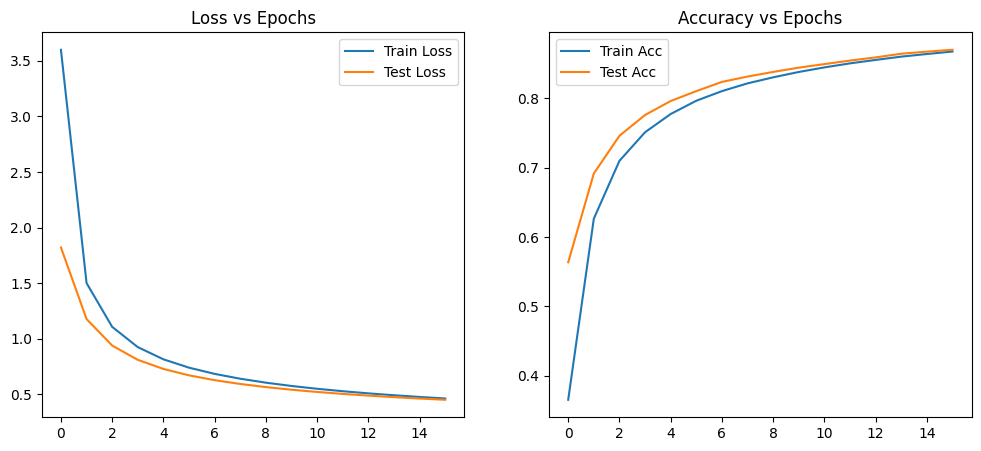

In [8]:
# === Plots ===
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss vs Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(test_accs, label="Test Acc")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()

In [9]:
students_ids = "340868488_340872084"
torch.save({"W1": model.W1, "W2": model.W2, "b1": model.b1, "b2": model.b2}, f"HW1_{students_ids}.pkl")

b. Train the model with various learning rates (at least 3).

Plot the model's accuracy and loss (both on train and test sets) as a function of the epochs.
Discuss the differences in training with different learning rates. Support your answer with plots.

In [10]:
def train_model(lr):

    model = FullyConnectedNetwork(784, 10, 128, sigmoid, lr=lr)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(EPOCHS):

        total_loss = 0
        total_acc = 0
        batches = 0

        # Train loop
        for X, y in train_dataloader:
            y_hat = model.forward(X)
            loss = cross_entropy(y, y_hat)
            model.backward(X, y, y_hat)

            total_loss += loss.item()
            total_acc += accuracy(y, y_hat)
            batches += 1

        train_losses.append(total_loss / batches)
        train_accs.append(total_acc / batches)

        # Test loop
        total_loss = 0
        total_acc = 0
        batches = 0

        for X, y in test_dataloader:
            y_hat = model.forward(X)
            loss = cross_entropy(y, y_hat)

            total_loss += loss.item()
            total_acc += accuracy(y, y_hat)
            batches += 1

        test_losses.append(total_loss / batches)
        test_accs.append(total_acc / batches)
        print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | "
          f"Train Acc: {train_accs[-1]:.4f} | Test Acc: {test_accs[-1]:.4f}")

    return train_losses, test_losses, train_accs, test_accs


Training with lr = 0.0001

Epoch 1/16 | Train Loss: 9.6635 | Test Loss: 8.8929 | Train Acc: 0.0916 | Test Acc: 0.0945
Epoch 2/16 | Train Loss: 8.3216 | Test Loss: 7.9128 | Train Acc: 0.1011 | Test Acc: 0.1102
Epoch 3/16 | Train Loss: 7.5497 | Test Loss: 7.3079 | Train Acc: 0.1135 | Test Acc: 0.1194
Epoch 4/16 | Train Loss: 7.0410 | Test Loss: 6.8800 | Train Acc: 0.1237 | Test Acc: 0.1302
Epoch 5/16 | Train Loss: 6.6652 | Test Loss: 6.5482 | Train Acc: 0.1323 | Test Acc: 0.1370
Epoch 6/16 | Train Loss: 6.3682 | Test Loss: 6.2785 | Train Acc: 0.1404 | Test Acc: 0.1436
Epoch 7/16 | Train Loss: 6.1247 | Test Loss: 6.0530 | Train Acc: 0.1475 | Test Acc: 0.1515
Epoch 8/16 | Train Loss: 5.9196 | Test Loss: 5.8595 | Train Acc: 0.1534 | Test Acc: 0.1573
Epoch 9/16 | Train Loss: 5.7419 | Test Loss: 5.6887 | Train Acc: 0.1596 | Test Acc: 0.1653
Epoch 10/16 | Train Loss: 5.5836 | Test Loss: 5.5341 | Train Acc: 0.1666 | Test Acc: 0.1707
Epoch 11/16 | Train Loss: 5.4392 | Test Loss: 5.3912 | Train 

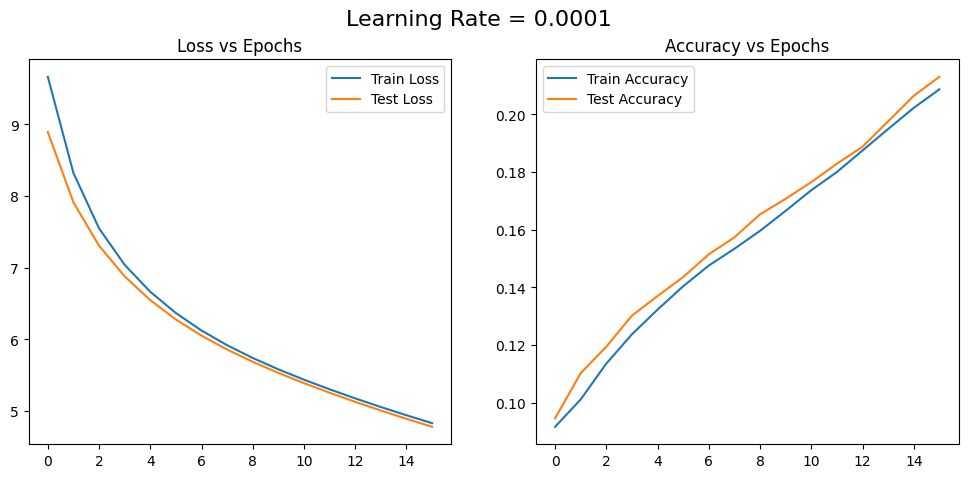


Training with lr = 0.001

Epoch 1/16 | Train Loss: 7.0523 | Test Loss: 5.2873 | Train Acc: 0.1177 | Test Acc: 0.1551
Epoch 2/16 | Train Loss: 4.7186 | Test Loss: 4.1778 | Train Acc: 0.1938 | Test Acc: 0.2375
Epoch 3/16 | Train Loss: 3.8742 | Test Loss: 3.5053 | Train Acc: 0.2717 | Test Acc: 0.3114
Epoch 4/16 | Train Loss: 3.3117 | Test Loss: 3.0272 | Train Acc: 0.3373 | Test Acc: 0.3766
Epoch 5/16 | Train Loss: 2.9034 | Test Loss: 2.6721 | Train Acc: 0.3925 | Test Acc: 0.4242
Epoch 6/16 | Train Loss: 2.5949 | Test Loss: 2.3989 | Train Acc: 0.4353 | Test Acc: 0.4651
Epoch 7/16 | Train Loss: 2.3546 | Test Loss: 2.1830 | Train Acc: 0.4723 | Test Acc: 0.5004
Epoch 8/16 | Train Loss: 2.1626 | Test Loss: 2.0085 | Train Acc: 0.5017 | Test Acc: 0.5302
Epoch 9/16 | Train Loss: 2.0061 | Test Loss: 1.8649 | Train Acc: 0.5301 | Test Acc: 0.5512
Epoch 10/16 | Train Loss: 1.8761 | Test Loss: 1.7451 | Train Acc: 0.5518 | Test Acc: 0.5726
Epoch 11/16 | Train Loss: 1.7666 | Test Loss: 1.6438 | Train A

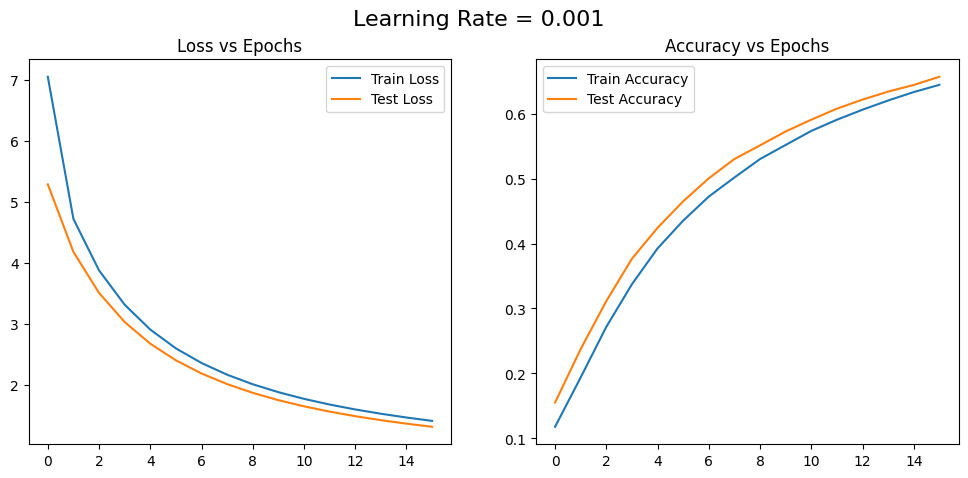


Training with lr = 0.1

Epoch 1/16 | Train Loss: 1.1335 | Test Loss: 0.5509 | Train Acc: 0.7282 | Test Acc: 0.8435
Epoch 2/16 | Train Loss: 0.4891 | Test Loss: 0.4262 | Train Acc: 0.8611 | Test Acc: 0.8776
Epoch 3/16 | Train Loss: 0.3865 | Test Loss: 0.3681 | Train Acc: 0.8878 | Test Acc: 0.8929
Epoch 4/16 | Train Loss: 0.3321 | Test Loss: 0.3334 | Train Acc: 0.9030 | Test Acc: 0.9013
Epoch 5/16 | Train Loss: 0.2974 | Test Loss: 0.3098 | Train Acc: 0.9121 | Test Acc: 0.9082
Epoch 6/16 | Train Loss: 0.2725 | Test Loss: 0.2924 | Train Acc: 0.9191 | Test Acc: 0.9131
Epoch 7/16 | Train Loss: 0.2533 | Test Loss: 0.2788 | Train Acc: 0.9244 | Test Acc: 0.9168
Epoch 8/16 | Train Loss: 0.2379 | Test Loss: 0.2677 | Train Acc: 0.9291 | Test Acc: 0.9195
Epoch 9/16 | Train Loss: 0.2249 | Test Loss: 0.2585 | Train Acc: 0.9327 | Test Acc: 0.9223
Epoch 10/16 | Train Loss: 0.2138 | Test Loss: 0.2506 | Train Acc: 0.9359 | Test Acc: 0.9241
Epoch 11/16 | Train Loss: 0.2041 | Test Loss: 0.2438 | Train Acc

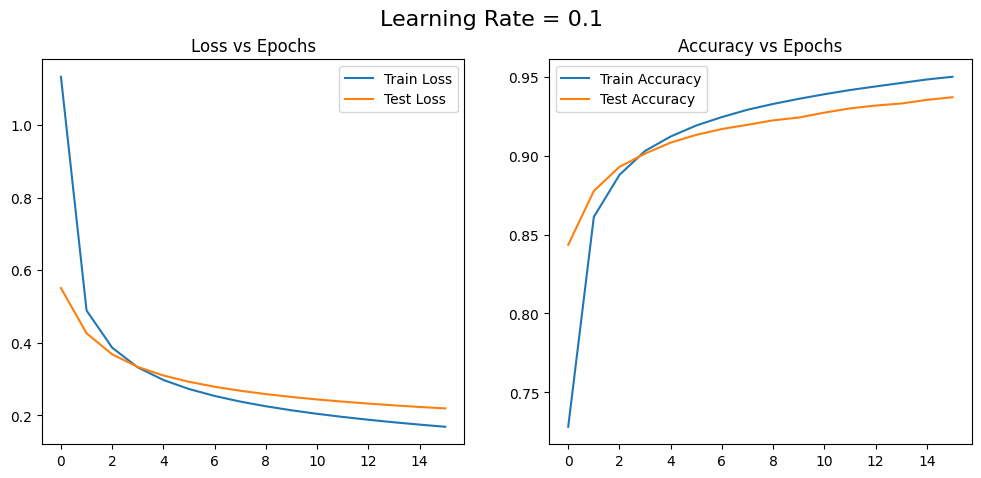

In [11]:
learning_rates = [0.0001, 0.001, 0.1]

results = {}

for lr in learning_rates:
    print(f"\nTraining with lr = {lr}\n")
    train_losses, test_losses, train_accs, test_accs = train_model(lr)

    results[lr] = (train_losses, test_losses, train_accs, test_accs)

    # --- Plots for this LR ---
    plt.figure(figsize=(12,5))
    plt.suptitle(f"Learning Rate = {lr}", fontsize=16)

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.title("Loss vs Epochs")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(test_accs, label="Test Accuracy")
    plt.title("Accuracy vs Epochs")
    plt.legend()

    plt.show()

We trained the same model with four different learning rates: 0.0001, 0.001, 0.01 and 0.1, and compared their losses and accuracies on both train and test sets.

• lr = 0.0001 (very small)

Training is extremely slow.
The loss decreases gradually but remains very high even after 16 epochs, and accuracy stays low (≈ 22%).
This learning rate is too small, causing underfitting and very slow convergence.

• lr = 0.001 (small)

The model learns better than with 0.0001: the loss decreases faster and accuracy reaches ≈ 67% after 16 epochs.
However, convergence is still relatively slow, and the model does not reach high accuracy within the given number of epochs.

• lr = 0.01 (medium, from part a)

This value achieves a good balance between stability and speed.
The loss decreases smoothly, and accuracy reaches around 85%.
This learning rate provides the best trade-off between convergence speed and overall performance.

• lr = 0.1 (large)

Training becomes much faster: loss drops sharply and accuracy rapidly reaches ≈ 93%.
However, the curves are more sensitive, and such a large learning rate can become unstable or diverge in other settings.
In this experiment it works well, but it has higher risk of instability.

Conclusion

The learning rate has a strong influence on both convergence and final performance.
Very small learning rates cause slow learning and underfitting, while very large ones accelerate training but may cause instability.
Moderate values (such as 0.01) generally give the most stable and reliable results.

# Question 4

We recommend using GPUs to solve this section. You can use free GPUs provided by Google Colab or by Kaggle (instructions on how to connect are in Moodle). Also, we recommend going over all tutorial notebooks and using dropout, normalization and Adam for better learning. Solving this on your personal computer will be significantly slower than using cloud computation.

## I. Implement and Train a CNN (30pt)

Whenever Ben sees a cat, his first instinct is to run up and pet them. However, after a recent incident he realized not all types of cats are very fond of that type of attention. Train a classifier to tell the difference between different types of big cats, and help Ben from putting himself in too much danger.

Your code should meet the following constraints:

1. Your classifier must be CNN based.
2. You are not allowed to use any pre-trained model.

#### Stages
1. Perform a short EDA (Exploratory Data Analysis).
2. Train the model and plot its accuracy and loss (for both the training and validation sets) as a function of the epochs. Display the overall number of parameters in the model. To see the number of parameters in your model, run `sum(p.numel() for p in model.parameters())`.
3. Report the test set accuracy.

 Your data is in `hw1_data/big_cats`.

You can use the provided code for preprocessing the data. You can also define a custom dataset (as in tutorial 3) or use `torchvision.datasets.ImageFolder` if you prefer. **Your training function must call the `set_seed` command for reproducibility**.

 #### Submission
In addition to the code in the notebook, you should submit:

1. a `.py` file containing your model class.
2. a `.pkl` file containing the weight of your model.

#### Grading
- 5 points for EDA.
- 15 points based on reaching minimum test accuracy (77% accuracy required to get all 15 points, 70% accuracy to get 10 points).
- 10 points competitive: try to balance the tradeoff between number of parameters in your model and model's test accuracy. The lower the # of parameters and the higher the test accuracy, the higher the final score.

In [12]:
# Mount Google Drive to access dataset stored in your Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import shutil
import os

src_path = "/content/drive/MyDrive/hw1_data/big_cats"
dst_path = "/content/big_cats_local"

# Remove previous copy if needed
if os.path.exists(dst_path):
    shutil.rmtree(dst_path)

# Copy folder (recursive)
shutil.copytree(src_path, dst_path)

print("Dataset copied successfully!")
print("New path:", dst_path)

Dataset copied successfully!
New path: /content/big_cats_local


In [14]:
############################
#   BIG CATS CLASSIFIER   #
############################

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import matplotlib.pyplot as plt

# --- reproducibility ---
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# --- device selection ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Classes: ['AFRICAN LEOPARD', 'CARACAL', 'CHEETAH', 'CLOUDED LEOPARD', 'JAGUAR', 'LIONS', 'OCELOT', 'PUMA', 'SNOW LEOPARD', 'TIGER']
Number of classes: 10
Train size: 2339
Valid size: 50 5 per class
Test size: 50 5 per class


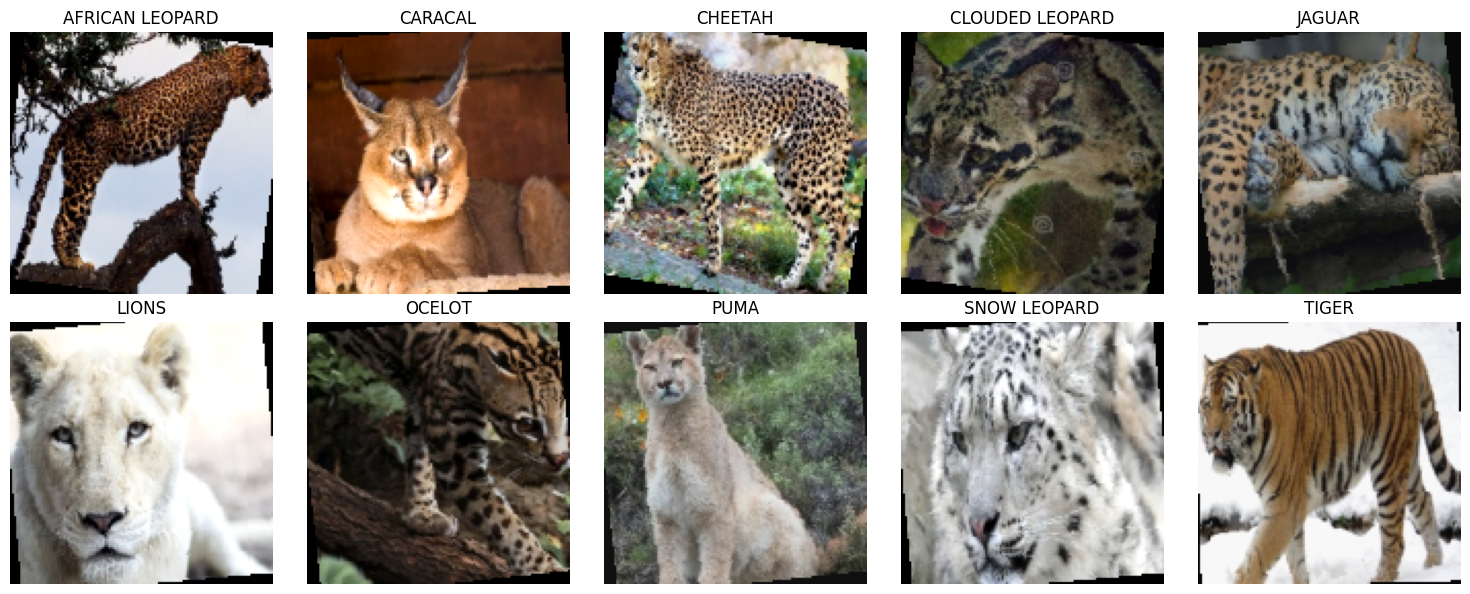

In [15]:
# --- paths ---
data_root = "/content/big_cats_local"  # or "/content/drive/MyDrive/hw1_data/big_cats"
train_dir = os.path.join(data_root, "train")
val_dir   = os.path.join(data_root, "valid")
test_dir  = os.path.join(data_root, "test")

# --- DATA AUGMENTATION (train only) ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# --- VALIDATION/TEST TRANSFORM (no augmentation) ---
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = ImageFolder(root=val_dir,   transform=test_transform)
test_dataset  = ImageFolder(root=test_dir,  transform=test_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train size:", len(train_dataset))
print("Valid size:", len(val_dataset), "5 per class")
print("Test size:", len(test_dataset), "5 per class")

# --- dataloaders ---
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

inv_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# --- EDA: show one sample per class ---

num_classes = len(class_names)

# compute rows & columns to display all classes nicely
cols = 5
rows = (num_classes + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(15, 6))
axs = axs.flatten()   # flatten grid to 1D list

shown = set()
ax_idx = 0

for img, label in train_dataset:
    class_name = class_names[label]

    if class_name in shown:
        continue

    shown.add(class_name)

    # de-normalize image
    img_show = img.permute(1, 2, 0).numpy() * 0.5 + 0.5

    axs[ax_idx].imshow(img_show)
    axs[ax_idx].set_title(class_name)
    axs[ax_idx].axis("off")

    ax_idx += 1

    if ax_idx >= num_classes:
        break

plt.tight_layout()
plt.show()

In [16]:
class BigCatsCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            # BLOCK 1 (32 → 24 channels)
            nn.Conv2d(3, 24, 3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.Conv2d(24, 24, 3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 -> 64

            # BLOCK 2 (64 → 48 channels)
            nn.Conv2d(24, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.Conv2d(48, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            # BLOCK 3 (128 → 96 channels)
            nn.Conv2d(48, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.Conv2d(96, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 32 -> 16
        )

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(96, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = BigCatsCNN(num_classes=num_classes).to(device)

print("Number of parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Number of parameters: 163330


In [17]:
# --- training setup ---
num_epochs = 50
learning_rate = 0.0007

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    ########################
    #      TRAINING
    ########################
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * correct / total

    ########################
    #      VALIDATION
    ########################
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100.0 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"| Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% "
          f"| Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

Epoch [1/50] | Train Loss: 1.9164, Acc: 28.94% | Val Loss: 1.6605, Acc: 32.00%
Epoch [2/50] | Train Loss: 1.6912, Acc: 36.64% | Val Loss: 1.6416, Acc: 34.00%
Epoch [3/50] | Train Loss: 1.5933, Acc: 41.30% | Val Loss: 1.6208, Acc: 50.00%
Epoch [4/50] | Train Loss: 1.5039, Acc: 44.16% | Val Loss: 1.4277, Acc: 60.00%
Epoch [5/50] | Train Loss: 1.4137, Acc: 48.01% | Val Loss: 1.5487, Acc: 40.00%
Epoch [6/50] | Train Loss: 1.3151, Acc: 51.05% | Val Loss: 1.2086, Acc: 50.00%
Epoch [7/50] | Train Loss: 1.2617, Acc: 54.38% | Val Loss: 1.4285, Acc: 50.00%
Epoch [8/50] | Train Loss: 1.2312, Acc: 54.17% | Val Loss: 1.5803, Acc: 52.00%
Epoch [9/50] | Train Loss: 1.2212, Acc: 56.26% | Val Loss: 1.1333, Acc: 58.00%
Epoch [10/50] | Train Loss: 1.1586, Acc: 56.26% | Val Loss: 1.3099, Acc: 58.00%
Epoch [11/50] | Train Loss: 1.1027, Acc: 59.94% | Val Loss: 1.1399, Acc: 62.00%
Epoch [12/50] | Train Loss: 1.0761, Acc: 61.78% | Val Loss: 1.0542, Acc: 52.00%
Epoch [13/50] | Train Loss: 1.0565, Acc: 61.69% |

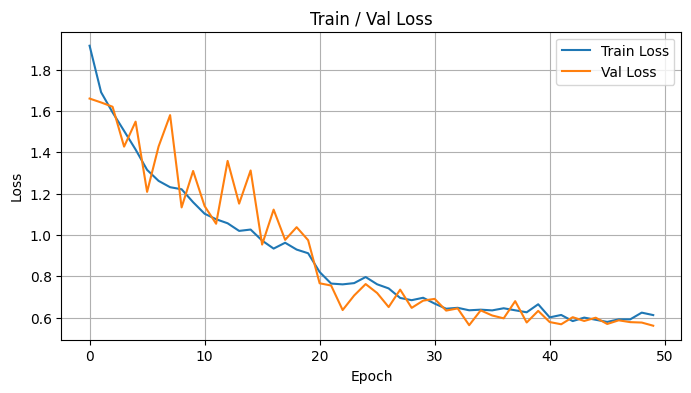

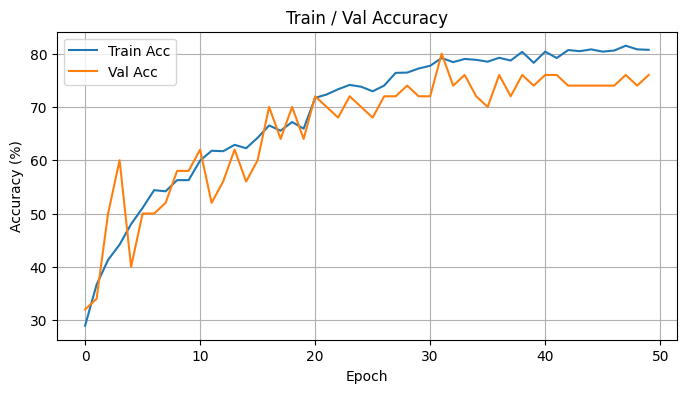

In [18]:
# --- plot losses ---
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss")
plt.legend()
plt.grid(True)
plt.show()

# --- plot accuracies ---
plt.figure(figsize=(8,4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train / Val Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# --- TEST PHASE ---
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100.0 * correct / total
print(f"\n🔥 TEST ACCURACY = {test_acc:.2f}%")

# --- SAVE MODEL WEIGHTS (.pkl) ---
pkl_path = "bigcats_340868488_340872084.pkl"
torch.save(model.state_dict(), pkl_path)
print("Model weights saved to:", pkl_path)




🔥 TEST ACCURACY = 86.00%
Model weights saved to: bigcats_340868488_340872084.pkl


## II. Analyzing a Pre-trained CNN (Filters) (10pt)

In this part, you are going to analyze a (large) pre-trained model. Pre-trained models are quite popular these days, as big companies can train really large models on large datasets (something that personal users can't do as they lack the sufficient hardware). These pre-trained models can be used to fine-tune on other/small datasets or used as components in other tasks (like using a pre-trained classifier for object detection).

All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

You can use the following transform to normalize:

`normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`
<a href="https://pytorch.org/vision/stable/models.html">Read more here</a>


1. Load a pre-trained VGG16 with PyTorch using `torchvision.models.vgg16(pretrained=True, progress=True, **kwargs)` (<a href="https://pytorch.org/vision/stable/models.html#classification">read more here</a>). Don't forget to use the model in evaluation mode (`model.eval()`).

2. Load the images in the `hw1_data/birds` folder and display them.

3. Pre-process the images to fit VGG16's architecture. What steps did you take?

4. Feed the images (forward pass) to the model. What are the outputs?

5. Choose an image of a dog in the `hw1_data/dogs` folder, display it and feed it to network. What are the outputs?

6. For the first 3 filters in the first layer of VGG16, plot their response (their output) for the image from section 5. Explain what do you see.

In [20]:
import torch
import torchvision
from torchvision.models import vgg16, VGG16_Weights

# Load pretrained VGG16 model
weights = VGG16_Weights.IMAGENET1K_V1
model = vgg16(weights=weights)

# Set model to evaluation mode
model.eval()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 90.3MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

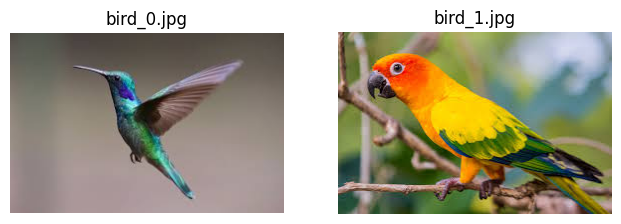

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Path to the birds folder
birds_path = "/content/drive/MyDrive/hw1_data/birds"

# Load all images
bird_images = []
image_names = []

for filename in os.listdir(birds_path):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(birds_path, filename)
        img = Image.open(img_path).convert("RGB")
        bird_images.append(img)
        image_names.append(filename)

# Display the images
plt.figure(figsize=(12, 8))
for i, img in enumerate(bird_images):
    plt.subplot(2, 3, i+1)  # adjust rows/cols depending on number of images
    plt.imshow(img)
    plt.title(image_names[i])
    plt.axis("off")

plt.show()

In [22]:
import torchvision.transforms as transforms

# Define VGG16 preprocessing transform
preprocess = transforms.Compose([
    transforms.Resize(256),               # Resize short side to 256
    transforms.CenterCrop(224),           # Crop to 224x224
    transforms.ToTensor(),                # Convert to Tensor (range 0–1)
    transforms.Normalize(                 # Normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Apply preprocessing to all bird images
processed_birds = []

for img in bird_images:
    img_tensor = preprocess(img)          # Apply transform
    img_tensor = img_tensor.unsqueeze(0)  # Add batch dimension (1,3,224,224)
    processed_birds.append(img_tensor)

print("Number of processed bird images:", len(processed_birds))
print("Shape of one processed image:", processed_birds[0].shape)

Number of processed bird images: 2
Shape of one processed image: torch.Size([1, 3, 224, 224])



Preprocessing steps:
To adapt the images to VGG16’s expected input format, we used the standard ImageNet preprocessing pipeline. Each image was:

	1.	Resized to 256 pixels on the shorter side.
	2.	Center-cropped to 224×224 (the required input size for VGG16).
	3.	Converted into a PyTorch tensor with pixel values in the range [0, 1].
	4.	Normalized using the official ImageNet mean and standard deviation values(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]).
Finally, a batch dimension was added to each processed image so that it matches the model input format (1, 3, 224, 224).

In [23]:
import torch.nn.functional as F
# Use ImageNet labels from pretrained weights
imagenet_labels = weights.meta["categories"]

def get_top5(output_tensor):
    """Return top-5 classes and probabilities."""
    probs = F.softmax(output_tensor, dim=1)
    top5_prob, top5_idx = probs.topk(5)
    return [
        (imagenet_labels[idx], float(prob))
        for idx, prob in zip(top5_idx[0], top5_prob[0])
    ]

# Run forward pass on all birds
bird_outputs = []
bird_predictions = []

with torch.no_grad():
    for img_tensor in processed_birds:
        out = model(img_tensor)              # (1,1000) logits
        bird_outputs.append(out)
        bird_predictions.append(get_top5(out))

# Display predictions
for i, preds in enumerate(bird_predictions):
    print(f"\nImage: {image_names[i]}")
    for cls, prob in preds:
        print(f"  {cls:25s}  —  {prob:.4f}")


Image: bird_0.jpg
  hummingbird                —  0.8644
  jacamar                    —  0.1355
  bee eater                  —  0.0002
  black stork                —  0.0000
  water ouzel                —  0.0000

Image: bird_1.jpg
  lorikeet                   —  0.9415
  macaw                      —  0.0401
  toucan                     —  0.0108
  bee eater                  —  0.0029
  goldfinch                  —  0.0017


Model outputs:
After preprocessing the bird images, we performed a forward pass through the pretrained VGG16 network.
The output of the model is a vector of 1000 logits, corresponding to the 1000 ImageNet classes.
To interpret these outputs, we applied a softmax and extracted the top-5 predicted classes for each image.

For both images, the model produced high-confidence predictions of bird species, showing that the pretrained VGG16 correctly recognizes the content:


•	For bird_0.jpg, the top prediction was hummingbird with ~86% confidence.


•	For bird_1.jpg, the top prediction was lorikeet with ~94% confidence.

These results demonstrate that pretrained models like VGG16 can generalize well to new images even without fine-tuning.

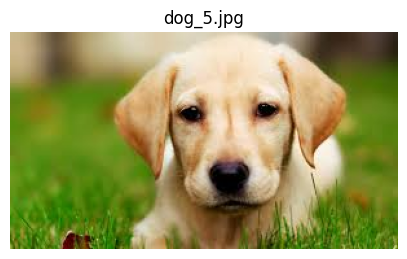


Top-5 predictions for the dog image:
  Labrador retriever        — 0.9547
  golden retriever          — 0.0448
  kuvasz                    — 0.0002
  redbone                   — 0.0001
  Rhodesian ridgeback       — 0.0000


In [24]:
# Path to dogs folder
dogs_path = "/content/drive/MyDrive/hw1_data/dogs"

# Select one dog image (you can change the index)
dog_filename = [f for f in os.listdir(dogs_path) if f.lower().endswith(("jpg","png","jpeg"))][0]
dog_path = os.path.join(dogs_path, dog_filename)

# Load and display the dog image
dog_img = Image.open(dog_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(dog_img)
plt.title(dog_filename)
plt.axis("off")
plt.show()

# Preprocess the dog image
dog_tensor = preprocess(dog_img).unsqueeze(0)

# Forward pass
with torch.no_grad():
    dog_output = model(dog_tensor)
    dog_top5 = get_top5(dog_output)

# Print predictions
print("\nTop-5 predictions for the dog image:")
for cls, prob in dog_top5:
    print(f"  {cls:25s} — {prob:.4f}")


Prediction on dog image:
We selected one image from the dogs folder, displayed it, preprocessed it using the standard VGG16 ImageNet pipeline, and performed a forward pass through the pretrained model.

The output is a vector of 1000 logits corresponding to the ImageNet classes. As before, we applied a softmax and extracted the top-5 predicted classes.

The model correctly recognized the dog. The top prediction was:

•	Labrador retriever with ~95% confidence,

followed by other dog breeds with much lower probabilities (e.g., golden retriever at ~4.4%).

This shows that VGG16 generalizes very well to unseen dog images and has strong discriminative power among similar dog breeds.

Activation shape: torch.Size([1, 64, 224, 224])


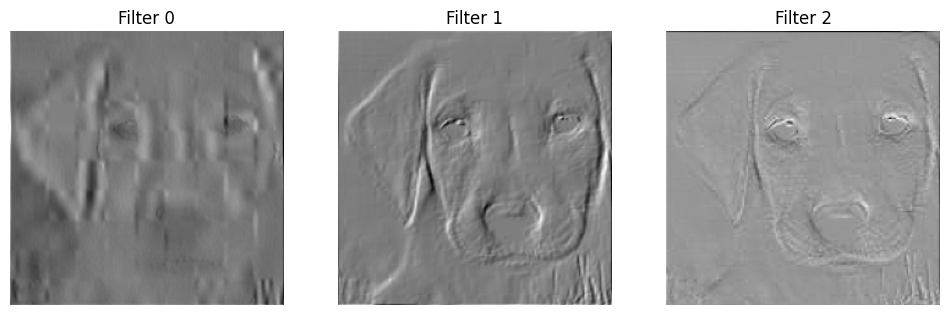

In [25]:
# First convolutional layer of VGG16
first_conv = model.features[0]

# Forward only through the first conv layer
with torch.no_grad():
    activation = first_conv(dog_tensor)     # shape (1, 64, 224, 224)

print("Activation shape:", activation.shape)

# Plot the responses of the first 3 filters
plt.figure(figsize=(12, 4))

for i in range(3):
    plt.subplot(1, 3, i+1)
    feature_map = activation[0, i].cpu().numpy()
    plt.imshow(feature_map, cmap='gray')
    plt.title(f"Filter {i}")
    plt.axis('off')

plt.show()


Visualizing early convolutional filters:
We extracted the activations of the first convolutional layer of VGG16 (features[0]) and applied it to the dog image.
This layer contains 64 filters, each producing a feature map of size 224×224.
We plotted the responses of the first 3 filters.

The visualizations show that the first convolutional layer detects very low-level visual features such as:


•	edges (horizontal, vertical, diagonal)

•	simple textures

•	local intensity changes

For example, Filter 1 and Filter 2 clearly highlight the dog’s eyes, nose, and head outline, because these regions contain strong edges and contrast transitions.
These patterns are typical of early CNN layers:
they do not recognize objects yet, but instead learn Gabor-like filters similar to edge detectors in classical computer vision.

This confirms the hierarchical nature of deep CNNs:
the first layers capture low-level structure, while deeper layers combine these into high-level semantic concepts (such as “dog”).